дані: https://www.kaggle.com/datasets/cybersimar08/drone-detection/data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import json, torch

import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from transformers import (
    RTDetrForObjectDetection,
    RTDetrImageProcessor,
    TrainingArguments,
    Trainer,
)

import re
import tempfile

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from transformers.trainer_utils import get_last_checkpoint

/Users/alina/Documents/Alina/education/kma/year3/term2/Deep Learning/code/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alina/Documents/Alina/education/kma/year3/term2/Deep Learning/code/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [3]:
DATA_ROOT = Path('archive/coco json drone detection')
SPLITS    = ['train', 'valid', 'test']

# Load data

In [4]:
def load_coco(split: str):
    split_dir  = DATA_ROOT / split
    json_files = list(split_dir.glob('*.json'))
    assert json_files, f'JSON не знайдено у {split_dir}'
    with open(json_files[0]) as f:
        return json.load(f), split_dir

# EDA

In [5]:
data = {}
for split in SPLITS:
    try:
        coco, img_dir       = load_coco(split)
        data[split]         = {'coco': coco, 'img_dir': img_dir}
        print(f'[{split:>5}]  зображень: {len(coco["images"]):>5} | '
              f'анотацій: {len(coco["annotations"]):>6}')
    except AssertionError as e:
        print(f'[{split}]  {e}')

[train]  зображень: 10799 | анотацій:   8999
[valid]  зображень:   603 | анотацій:    497
[ test]  зображень:   596 | анотацій:    479


In [6]:
def build_df(coco: dict) -> pd.DataFrame:
    img_map = {img['id']: img for img in coco['images']}
    rows = []
    for ann in coco['annotations']:
        img      = img_map[ann['image_id']]
        x, y, w, h = ann['bbox']
        rows.append({
            'image_id' : ann['image_id'],
            'img_w'    : img['width'],
            'img_h'    : img['height'],
            'bbox_x'   : x,  'bbox_y': y,
            'bbox_w'   : w,  'bbox_h': h,
            'area'     : ann.get('area', w * h),
            'cx_rel'   : (x + w / 2) / img['width'],
            'cy_rel'   : (y + h / 2) / img['height'],
            'w_rel'    : w / img['width'],
            'h_rel'    : h / img['height'],
            'aspect'   : w / (h + 1e-6),
            'file_name': img['file_name'],
        })
    return pd.DataFrame(rows)

dfs    = {split: build_df(data[split]['coco']) for split in data}
df_all = (pd.concat(dfs.values(), keys=dfs.keys())
            .reset_index(level=0)
            .rename(columns={'level_0': 'split'}))

print('Статистика bbox')
df_all.groupby('split')[['bbox_w', 'bbox_h', 'area', 'aspect']].describe().round(1)

Статистика bbox


bbox_w                                             bbox_h        ...  \
        count  mean   std   min   25%   50%   75%    max   count  mean  ...   
split                                                                   ...   
test    479.0  54.9  42.9  16.0  29.5  38.5  63.2  275.5   479.0  57.2  ...   
train  8999.0  56.7  48.7   9.0  29.0  38.0  62.5  371.0  8999.0  56.1  ...   
valid   497.0  58.9  52.2  12.5  28.5  39.0  66.0  363.5   497.0  58.4  ...   

         area            aspect                                     
          75%       max   count mean  std  min  25%  50%  75%  max  
split                                                               
test   3818.5   94358.8   479.0  1.0  0.2  0.5  0.9  1.0  1.1  1.8  
train  3593.4  112112.0  8999.0  1.0  0.3  0.3  0.9  1.0  1.2  8.2  
valid  4168.8  112866.8   497.0  1.0  0.2  0.6  0.9  1.0  1.2  2.3  

[3 rows x 32 columns]

In [7]:
def extract_class_from_filename(filename: str) -> str:
    """
    V_DRONE_036146_...   - 'drone'
    V_AIRPLANE_0011_...  - 'airplane'
    V_HELICOPTER_047_... - 'helicopter'
    V_BIRD_01271_...     - 'bird'
    """
    match = re.match(r'V_([A-Z]+)_', Path(filename).name)
    if match:
        return match.group(1).lower()
    return 'unknown'

df_all['true_class'] = df_all['file_name'].apply(extract_class_from_filename)

print('Розподіл класів')
display(df_all.groupby(['split', 'true_class']).size()
              .unstack(fill_value=0)
              .assign(TOTAL=lambda d: d.sum(axis=1)))

Розподіл класів


true_class,airplane,bird,drone,helicopter,TOTAL
split,,,,,
test,128,0,237,114,479
train,2274,2,4349,2374,8999
valid,133,0,224,140,497


In [8]:
df_all_no_birds = df_all[df_all['true_class'] != 'bird']

In [9]:
print('Розподіл класів')
display(df_all_no_birds.groupby(['split', 'true_class']).size()
              .unstack(fill_value=0)
              .assign(TOTAL=lambda d: d.sum(axis=1)))

Розподіл класів


true_class,airplane,drone,helicopter,TOTAL
split,,,,
test,128,237,114,479
train,2274,4349,2374,8997
valid,133,224,140,497


In [10]:
print("Середні розміри зображень по сетах:")
print("-" * 40)

for split, df in dfs.items():
    
    avg_w = df['img_w'].mean()
    avg_h = df['img_h'].mean()
    count = len(df)
    
    print(f"{split.upper():<7} | К-сть: {count:>5} | Середня Ш: {avg_w:>7.1f} px | Середня В: {avg_h:>7.1f} px")

Середні розміри зображень по сетах:
----------------------------------------
TRAIN   | К-сть:  8999 | Середня Ш:   640.0 px | Середня В:   640.0 px
VALID   | К-сть:   497 | Середня Ш:   640.0 px | Середня В:   640.0 px
TEST    | К-сть:   479 | Середня Ш:   640.0 px | Середня В:   640.0 px


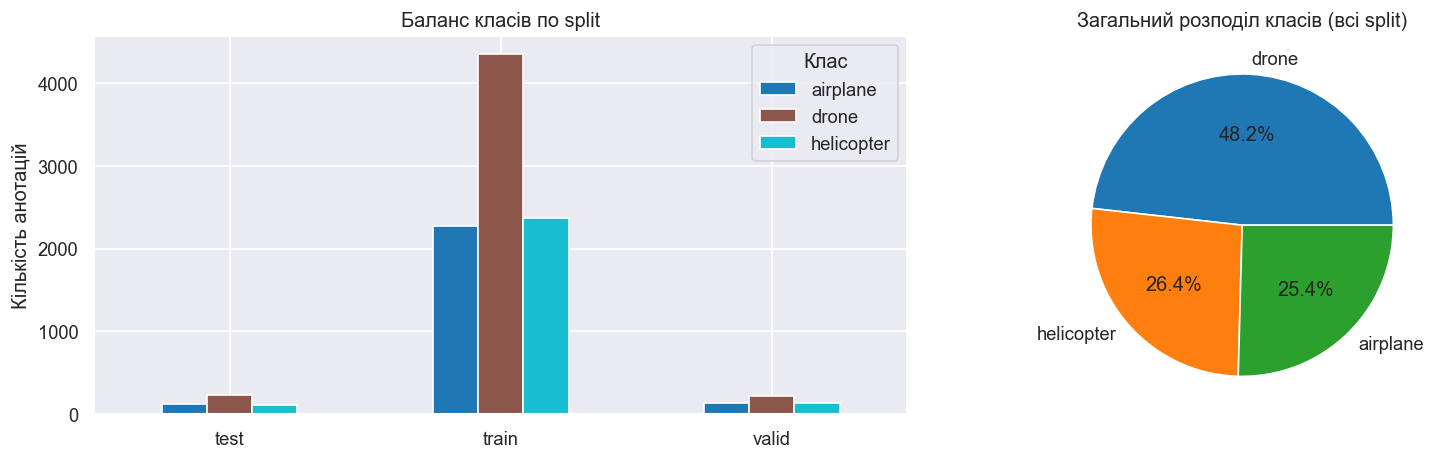

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
class_counts = df_all_no_birds.groupby(['split','true_class']).size().unstack(fill_value=0)
class_counts.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set(ylabel='Кількість анотацій', xlabel='', title='Баланс класів по split')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Клас')

ax = axes[1]
total_by_class = df_all_no_birds['true_class'].value_counts()
ax.pie(total_by_class.values, labels=total_by_class.index,
       autopct='%1.1f%%', colors=plt.cm.tab10.colors[:len(total_by_class)])
ax.set_title('Загальний розподіл класів (всі split)')

plt.tight_layout(); plt.show()

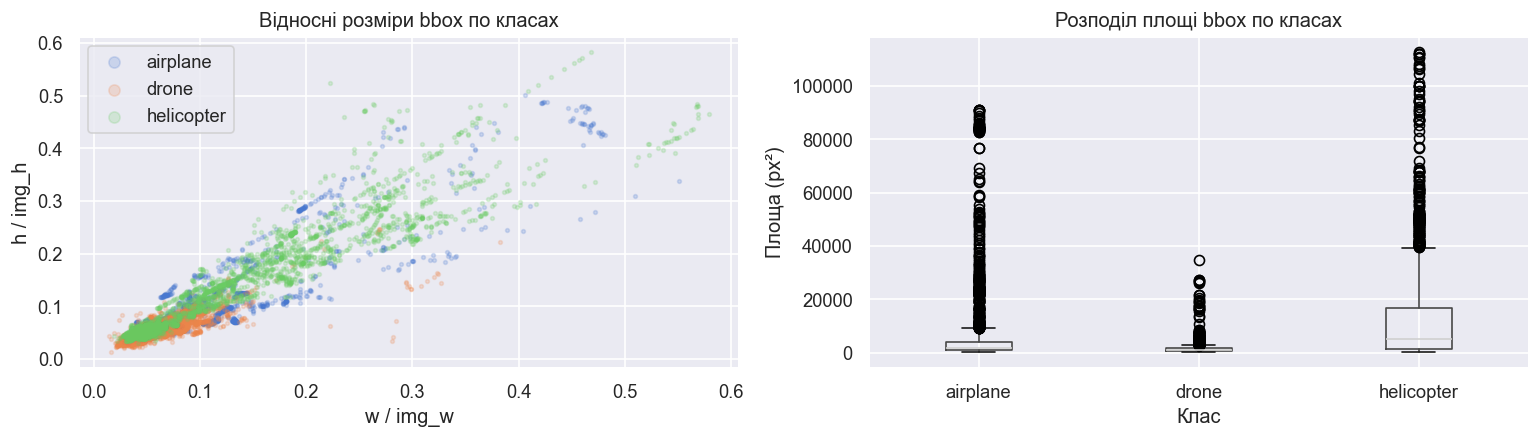

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for cls, grp in df_all_no_birds.groupby('true_class'):
    ax.scatter(grp['w_rel'], grp['h_rel'], alpha=0.2, s=5, label=cls)
ax.set(xlabel='w / img_w', ylabel='h / img_h',
       title='Відносні розміри bbox по класах')
ax.legend(markerscale=3)

ax = axes[1]
df_all_no_birds.boxplot(column='area', by='true_class', ax=ax)
ax.set(xlabel='Клас', ylabel='Площа (px²)', title='Розподіл площі bbox по класах')
plt.suptitle('')
plt.tight_layout(); plt.show()

переважно по 1 обʼєкту на картинку

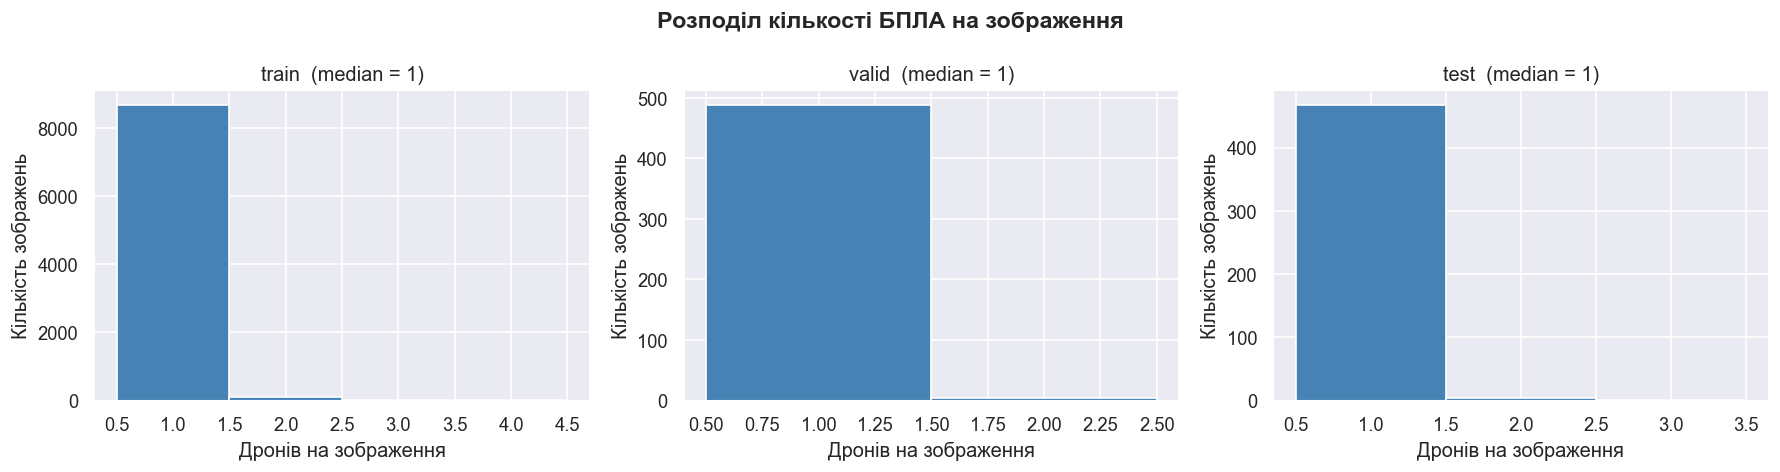

In [15]:
fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4), sharey=False)
if len(dfs) == 1:
    axes = [axes]

for ax, (split, df) in zip(axes, dfs.items()):
    counts = df.groupby('image_id').size()
    ax.hist(counts, bins=range(1, counts.max() + 2),
            color='steelblue', edgecolor='white', align='left')
    ax.set_title(f'{split}  (median = {counts.median():.0f})')
    ax.set_xlabel('Дронів на зображення')
    ax.set_ylabel('Кількість зображень')

fig.suptitle('Розподіл кількості БПЛА на зображення', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

розподіл "особливостей" між трейн, тест, валід даними +- однаковий

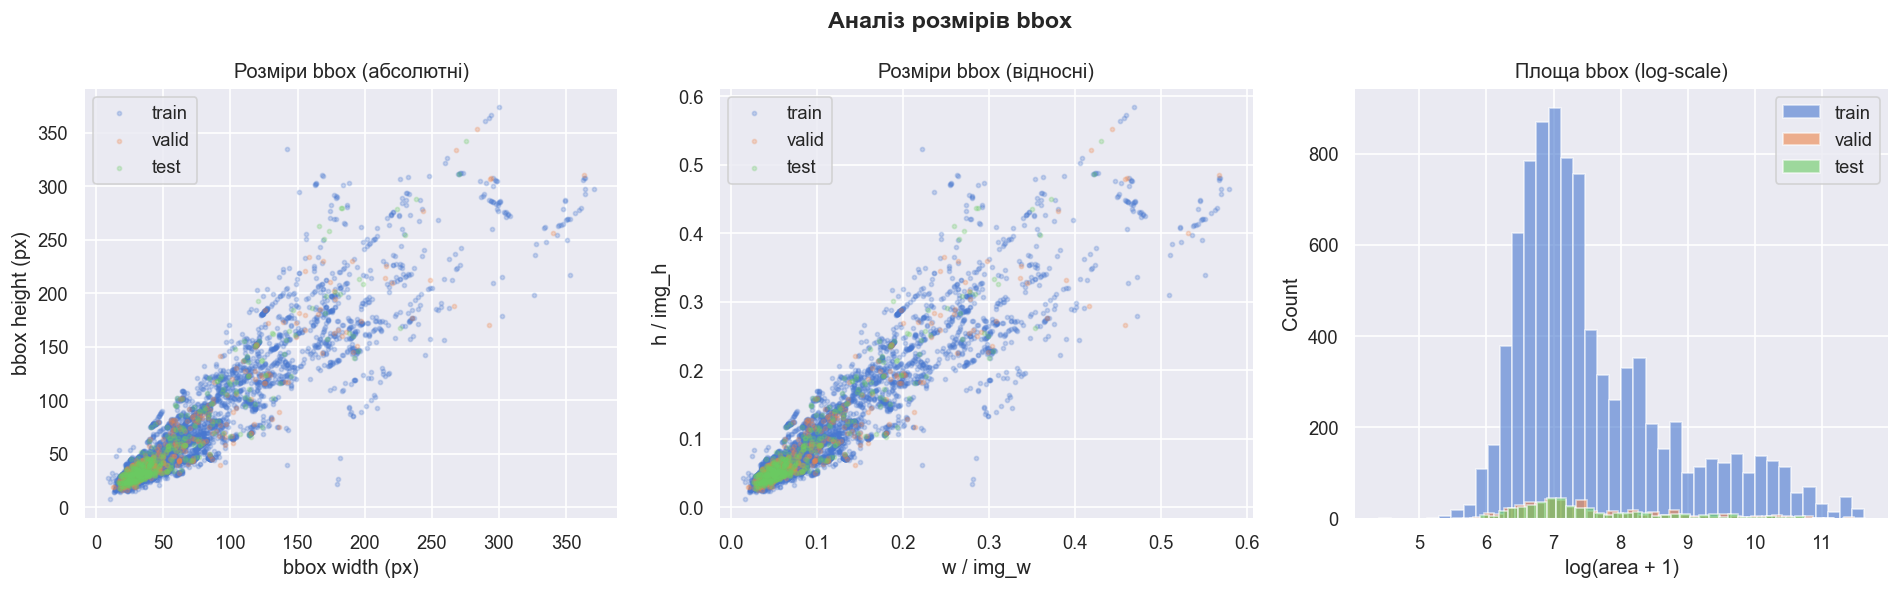

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# абсолютні розміри
ax = axes[0]
for split, df in dfs.items():
    ax.scatter(df['bbox_w'], df['bbox_h'], alpha=0.25, s=6, label=split)
ax.set(xlabel='bbox width (px)', ylabel='bbox height (px)',
       title='Розміри bbox (абсолютні)')
ax.legend()

# відносні розміри
ax = axes[1]
for split, df in dfs.items():
    ax.scatter(df['w_rel'], df['h_rel'], alpha=0.25, s=6, label=split)
ax.set(xlabel='w / img_w', ylabel='h / img_h',
       title='Розміри bbox (відносні)')
ax.legend()

# log-площа
ax = axes[2]
for split, df in dfs.items():
    ax.hist(np.log1p(df['area']), bins=40, alpha=0.6, label=split)
ax.set(xlabel='log(area + 1)', ylabel='Count', title='Площа bbox (log-scale)')
ax.legend()

fig.suptitle('Аналіз розмірів bbox', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

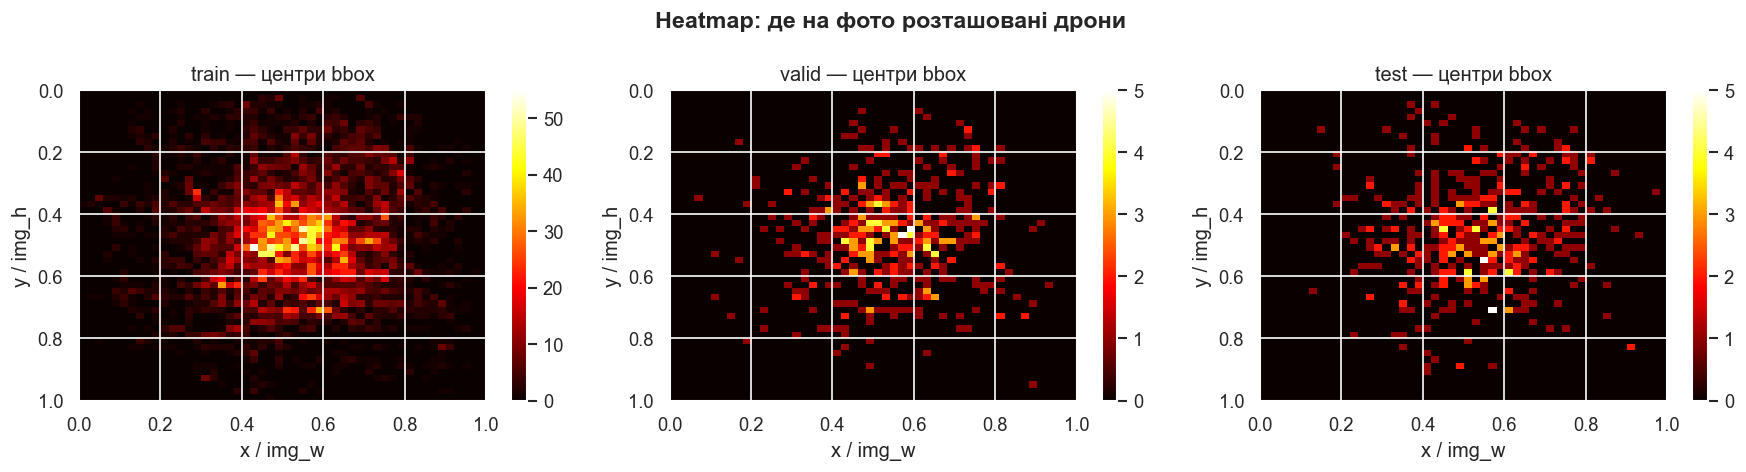

In [17]:
BINS = 50
fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4))
if len(dfs) == 1:
    axes = [axes]

for ax, (split, df) in zip(axes, dfs.items()):
    h, xe, ye = np.histogram2d(df['cx_rel'], df['cy_rel'],
                                bins=BINS, range=[[0,1],[0,1]])
    im = ax.imshow(h.T, origin='upper', cmap='hot',
                   aspect='auto', extent=[0,1,1,0])
    plt.colorbar(im, ax=ax)
    ax.set(title=f'{split} — центри bbox',
           xlabel='x / img_w', ylabel='y / img_h')

fig.suptitle('Heatmap: де на фото розташовані дрони', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

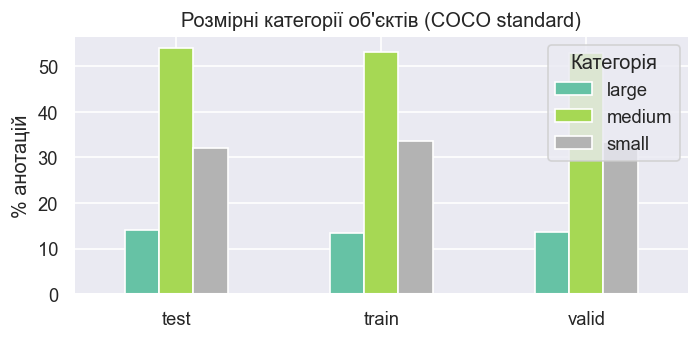


Абсолютна кількість:


size_cat,large,medium,small
split,,,
test,67,258,154
train,1198,4770,3031
valid,68,263,166


In [18]:
# COCO: small < 32^2, medium 32^2–96^2, large > 96^2
def size_cat(area):
    if area < 32**2: return 'small'
    if area < 96**2: return 'medium'
    return 'large'

df_all['size_cat'] = df_all['area'].apply(size_cat)

pivot     = df_all.groupby(['split','size_cat']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(6, 3))
pivot_pct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set(ylabel='% анотацій', xlabel='',
       title="Розмірні категорії об'єктів (COCO standard)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Категорія')
plt.tight_layout(); plt.show()

print('\nАбсолютна кількість:')
display(pivot)

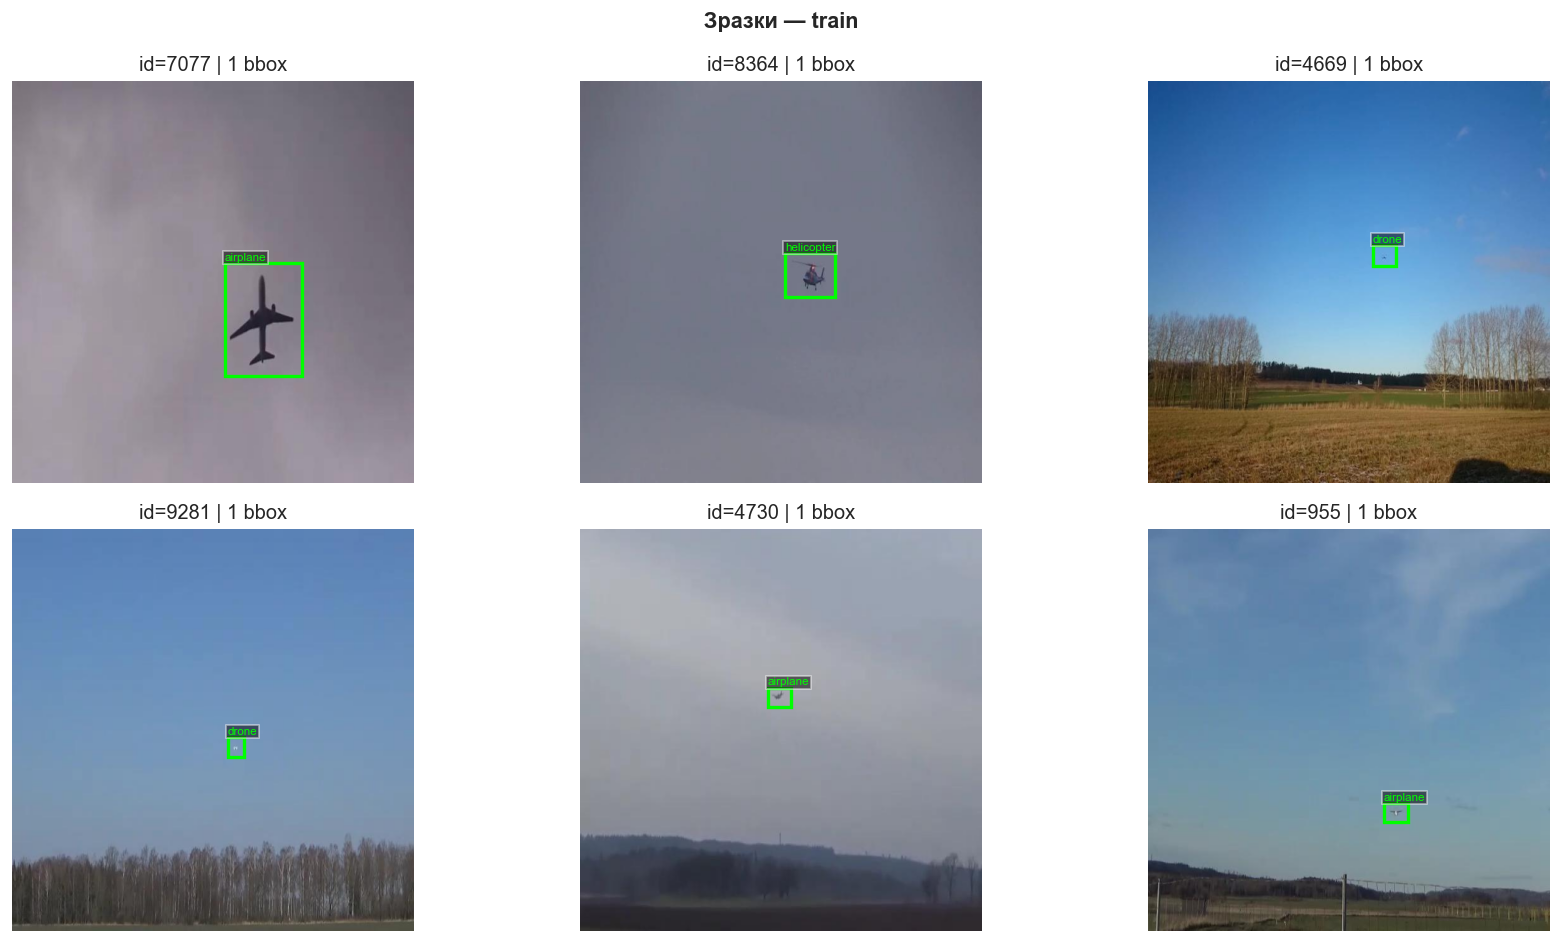

In [19]:
def show_samples(split: str, n: int = 6, seed: int = 42):
    coco    = data[split]['coco']
    img_dir = data[split]['img_dir']
    img_map = {img['id']: img for img in coco['images']}

    ann_map: dict[int, list] = {}
    for ann in coco['annotations']:
        ann_map.setdefault(ann['image_id'], []).append(ann)

    rng = np.random.default_rng(seed)
    ids = rng.choice(list(ann_map.keys()),
                     size=min(n, len(ann_map)), replace=False)

    cols = 3
    rows = (len(ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).flatten()

    for ax, img_id in zip(axes, ids):
        meta  = img_map[img_id]
        fpath = img_dir / meta['file_name']
        if not fpath.exists():
            fpath = next(img_dir.rglob(Path(meta['file_name']).name), None)
        if not fpath or not fpath.exists():
            ax.axis('off'); continue

        img = np.array(Image.open(fpath).convert('RGB'))
        ax.imshow(img)
        for ann in ann_map[img_id]:
            x, y, w, h = ann['bbox']
            class_name = extract_class_from_filename(meta['file_name'])
            ax.add_patch(patches.Rectangle(
                (x, y), w, h,
                linewidth=2, edgecolor='lime', facecolor='none'))
            ax.text(x, y - 4, class_name, color='lime', fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))
        ax.set_title(f'id={img_id} | {len(ann_map[img_id])} bbox')
        ax.axis('off')

    for ax in axes[len(ids):]:
        ax.axis('off')
    fig.suptitle(f'Зразки — {split}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

show_samples('train', n=6)

# Model

In [20]:
OUTPUT_DIR = Path('rtdetr_drone')
OUTPUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ['drone', 'airplane', 'helicopter']
ID2LABEL    = {i: name for i, name in enumerate(CLASS_NAMES)}
LABEL2ID    = {name: i for i, name in enumerate(CLASS_NAMES)}

MODEL_ID = 'PekingU/rtdetr_r50vd'

IMG_SIZE   = 640
BATCH_SIZE = 4      # до 2 якщо OOM
GRAD_ACCUM = 4      # ефективний batch = 16
NUM_EPOCHS = 50
LR         = 1e-4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cpu


In [21]:
def class_name_from_filename(filename: str) -> str:
    match = re.match(r'V_([A-Z]+)_', Path(filename).name)
    return match.group(1).lower() if match else 'unknown'

def class_id_from_filename(filename: str) -> int:
    return LABEL2ID.get(class_name_from_filename(filename), 0)

synt

In [31]:
def yolo_to_coco(box, img_w, img_h):
    x_c, y_c, w, h = box

    x_min = (x_c - w / 2) * img_w
    y_min = (y_c - h / 2) * img_h
    w     = w * img_w
    h     = h * img_h

    return [x_min, y_min, w, h]

In [32]:
def load_synthetic_to_coco(images_dir: Path, labels_dir: Path):
    images = []
    annotations = []

    ann_id = 0
    img_id = 0

    for img_path in sorted(images_dir.glob('*')):
        image = Image.open(img_path)
        w, h = image.size

        images.append({
            'id': img_id,
            'file_name': img_path.name,
            'width': w,
            'height': h,
        })

        label_path = labels_dir / (img_path.stem + '.txt')

        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    cls, x, y, bw, bh = map(float, line.strip().split())

                    bbox = yolo_to_coco((x, y, bw, bh), w, h)

                    annotations.append({
                        'id': ann_id,
                        'image_id': img_id,
                        'category_id': int(cls),
                        'bbox': bbox,
                        'area': bbox[2] * bbox[3],
                        'iscrowd': 0,
                    })

                    ann_id += 1

        img_id += 1

    return {
        'images': images,
        'annotations': annotations,
    }

In [33]:
def merge_coco(base, extra):
    max_img_id = max(img['id'] for img in base['images']) + 1
    max_ann_id = max(ann['id'] for ann in base['annotations']) + 1

    # shift images
    for img in extra['images']:
        img['id'] += max_img_id

    # shift annotations
    for ann in extra['annotations']:
        ann['id'] += max_ann_id
        ann['image_id'] += max_img_id

    return {
        **base,
        'images': base['images'] + extra['images'],
        'annotations': base['annotations'] + extra['annotations'],
    }

In [36]:
EXCLUDE_CLASSES = ['bird']

def filter_coco(split: str) -> dict:
    split_dir = DATA_ROOT / split
    json_path = next(split_dir.glob('*.json'))
    with open(json_path) as f:
        coco = json.load(f)

    excluded_ids = {
        img['id']
        for img in coco['images']
        if class_name_from_filename(img['file_name']) in EXCLUDE_CLASSES
    }

    clean_images = [img for img in coco['images']
                    if img['id'] not in excluded_ids]
    clean_anns   = [ann for ann in coco['annotations']
                    if ann['image_id'] not in excluded_ids]

    removed = len(coco['images']) - len(clean_images)
    print(f'[{split:>5}]  видалено: {removed:>3} | '
          f'залишилось: {len(clean_images):>5} зображень, '
          f'{len(clean_anns):>6} анотацій')

    return {**coco, 'images': clean_images, 'annotations': clean_anns}

synthetic_coco = load_synthetic_to_coco(
    DATA_ROOT / '/Users/alina/Documents/Alina/education/kma/year3/term2/Deep Learning/synthetic-drone-dataset-2k/images',
    DATA_ROOT / '/Users/alina/Documents/Alina/education/kma/year3/term2/Deep Learning/synthetic-drone-dataset-2k/labels'
)


clean_cocos = {split: filter_coco(split) for split in ['train', 'valid', 'test']}

print("after adding synthetic data:")
clean_cocos['train'] = merge_coco(clean_cocos['train'], synthetic_coco)
for split in SPLITS:
    coco = clean_cocos[split]
    print(f'[{split:>5}]  зображень: {len(coco["images"]):>5} | '
          f'анотацій: {len(coco["annotations"]):>6}')

[train]  видалено: 1978 | залишилось:  8821 зображень,   8997 анотацій
[valid]  видалено: 109 | залишилось:   494 зображень,    497 анотацій
[ test]  видалено: 123 | залишилось:   473 зображень,    479 анотацій
after adding synthetic data:
[train]  зображень: 10821 | анотацій:  10997
[valid]  зображень:   494 | анотацій:    497
[ test]  зображень:   473 | анотацій:    479


In [23]:
class DroneDetectionDataset(Dataset):
    def __init__(self, split: str, processor, augment: bool = False):
        self.img_dir   = DATA_ROOT / split
        self.processor = processor
        self.augment   = augment

        coco = clean_cocos[split]

        self.images  = coco['images']
        self.img_map = {img['id']: img for img in self.images}

        self.ann_map: dict[int, list] = {}
        for ann in coco['annotations']:
            self.ann_map.setdefault(ann['image_id'], []).append(ann)

    def __len__(self):
        return len(self.images)

    def _find_image(self, file_name: str) -> Path:
        p = self.img_dir / file_name
        if p.exists():
            return p
        return next(self.img_dir.rglob(Path(file_name).name))

    def __getitem__(self, idx: int):
        meta   = self.images[idx]
        img_id = meta['id']
        image  = Image.open(self._find_image(meta['file_name'])).convert('RGB')

        anns   = self.ann_map.get(img_id, [])
        boxes  = [ann['bbox'] for ann in anns]

        label  = class_id_from_filename(meta['file_name'])
        labels = [label] * len(anns)

        target = {
            'image_id': img_id,
            'annotations': [
                {
                    'bbox'       : b,
                    'category_id': l,
                    'iscrowd'    : 0,
                    'area'       : b[2] * b[3],
                }
                for b, l in zip(boxes, labels)
            ]
        }

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors='pt',
        )

        ret = {}
        for k, v in encoding.items():
            if torch.is_tensor(v):
                ret[k] = v.squeeze(0)
                
                if 'labels' in ret and 'class_labels' not in ret:
                    ret['class_labels'] = ret.pop('labels')
                
            else:
                labels_list = v

                for labels_dict in labels_list:
                    if 'labels' in labels_dict and 'class_labels' not in labels_dict:
                        labels_dict['class_labels'] = labels_dict.pop('labels')

                ret[k] = labels_list
        
        return ret

In [24]:
# def collate_fn(batch):
#     pixel_values = torch.stack([b['pixel_values'] for b in batch])
#     labels = [
#         {k: v for k, v in b.items() if k != 'pixel_values'}
#         for b in batch
#     ]
#     return {'pixel_values': pixel_values, 'labels': labels}

def collate_fn(batch):
    pixel_values = torch.stack([b['pixel_values'] for b in batch])
    
    labels = [
        b['labels'][0]
        for b in batch
    ]

    return {
        'pixel_values': pixel_values,
        'labels': labels
    }


processor = RTDetrImageProcessor.from_pretrained(
    MODEL_ID,
    size={'width': IMG_SIZE, 'height': IMG_SIZE},
)

train_ds = DroneDetectionDataset('train', processor, augment=True)
valid_ds = DroneDetectionDataset('valid', processor, augment=False)
test_ds  = DroneDetectionDataset('test',  processor, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                            shuffle=True,  collate_fn=collate_fn,
                            num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE,
                            shuffle=False, collate_fn=collate_fn,
                            num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds):>5} зображень | {len(train_loader):>4} батчів')
print(f'Valid: {len(valid_ds):>5} зображень | {len(valid_loader):>4} батчів')
print(f'Test:  {len(test_ds):>5} зображень')

Train:  8821 зображень | 2206 батчів
Valid:   494 зображень |  124 батчів
Test:    473 зображень


In [25]:
sample = train_ds[0]

print(type(sample['labels']))
print(sample['labels'][0].keys())

<class 'list'>
KeysView({'size': tensor([640, 640]), 'image_id': tensor([0]), 'class_labels': tensor([2]), 'boxes': tensor([[0.5281, 0.5199, 0.2562, 0.2367]]), 'area': tensor([24846.]), 'iscrowd': tensor([0]), 'orig_size': tensor([640, 640])})


In [26]:
model = RTDetrForObjectDetection.from_pretrained(
    MODEL_ID,
    num_labels=len(ID2LABEL),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Параметрів всього:    {total/1e6:.1f}M')
print(f'Тренованих:           {trainable/1e6:.1f}M')
print(f'Класів:               {list(ID2LABEL.values())}')

Some weights of RTDetrForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_r50vd and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([3]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([3]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([3]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- model.decoder.cl

Параметрів всього:    42.7M
Тренованих:           42.7M
Класів:               ['drone', 'airplane', 'helicopter']


In [27]:
args = TrainingArguments(
    output_dir                  = str(OUTPUT_DIR),
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LR,
    lr_scheduler_type           = 'cosine',
    warmup_ratio                = 0.05,
    weight_decay                = 1e-4,

    logging_dir                 = str(OUTPUT_DIR / 'logs'),
    logging_steps               = 20,
    eval_strategy               = 'steps',
    eval_steps                  = 500,
    save_strategy               = "steps",
    save_steps                  = 500,
    save_total_limit            = 3,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',

    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 0,
    remove_unused_columns       = False,
    report_to                   = ['tensorboard'],
)

In [28]:
class DetectionTrainer(Trainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(
            pixel_values=inputs['pixel_values'],
            labels=inputs['labels'],
        )
        return (outputs.loss, outputs) if return_outputs else outputs.loss

    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix='eval'):
        metrics = super().evaluate(eval_dataset, ignore_keys, metric_key_prefix)
        metrics.update(self._compute_map(eval_dataset or self.eval_dataset))
        self.log(metrics)
        return metrics

    @torch.no_grad()
    def _compute_map(self, dataset) -> dict:
        self.model.eval()
        
        self.model.to(DEVICE)
        
        loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                            collate_fn=collate_fn, num_workers=0)

        coco_gt_dict = {
            'images'    : [],
            'annotations': [],
            'categories': [{'id': i, 'name': n} for i, n in ID2LABEL.items()],
        }
        coco_dt_list = []
        ann_id = 0

        for batch in loader:
            pixel_values = batch['pixel_values'].to(DEVICE)
            labels       = batch['labels']

            outputs = self.model(pixel_values=pixel_values)

            orig_sizes = torch.tensor(
                [[l['orig_size'][0], l['orig_size'][1]] for l in labels]
            ).to(DEVICE)

            results = processor.post_process_object_detection(
                outputs,
                threshold=0.3,
                target_sizes=orig_sizes,
            )

            for res, lbl in zip(results, labels):
                img_id = int(lbl['image_id'])
                H = int(lbl['orig_size'][0])
                W = int(lbl['orig_size'][1])

                coco_gt_dict['images'].append(
                    {'id': img_id, 'width': W, 'height': H}
                )

                for box, cls in zip(lbl['boxes'], lbl['class_labels']):
                    x1, y1, x2, y2 = box.tolist()
                    x1, y1, x2, y2 = x1*W, y1*H, x2*W, y2*H
                    coco_gt_dict['annotations'].append({
                        'id'         : ann_id,
                        'image_id'   : img_id,
                        'category_id': int(cls),
                        'bbox'       : [x1, y1, x2-x1, y2-y1],
                        'area'       : (x2-x1) * (y2-y1),
                        'iscrowd'    : 0,
                    })
                    ann_id += 1

                for score, cls, box in zip(
                    res['scores'].tolist(),
                    res['labels'].tolist(),
                    res['boxes'].tolist(),
                ):
                    x1, y1, x2, y2 = box
                    coco_dt_list.append({
                        'image_id'   : img_id,
                        'category_id': cls,
                        'bbox'       : [x1, y1, x2-x1, y2-y1],
                        'score'      : score,
                    })

        if not coco_dt_list:
            print('Жодного передбачення — threshold занадто високий?')
            return {'eval_mAP50_95': 0., 'eval_mAP50': 0.}

        with tempfile.NamedTemporaryFile(
            mode='w', suffix='.json', delete=False
        ) as f:
            json.dump(coco_gt_dict, f)
            gt_path = f.name

        coco_gt   = COCO(gt_path)
        coco_dt   = coco_gt.loadRes(coco_dt_list)
        coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()

        metrics = {
            'eval_mAP50_95' : round(coco_eval.stats[0], 4),
            'eval_mAP50'    : round(coco_eval.stats[1], 4),
            'eval_mAP_small': round(coco_eval.stats[3], 4),
            'eval_mAP_med'  : round(coco_eval.stats[4], 4),
            'eval_mAP_large': round(coco_eval.stats[5], 4),
        }

        # per-class AP50
        for cls_id, cls_name in ID2LABEL.items():
            coco_eval.params.catIds = [cls_id]
            coco_eval.evaluate()
            coco_eval.accumulate()
            metrics[f'eval_AP50_{cls_name}'] = round(coco_eval.stats[1], 4)

        return metrics

In [29]:
trainer = DetectionTrainer(
    model          = model,
    args           = args,
    train_dataset  = train_ds,
    eval_dataset   = valid_ds,
    data_collator  = collate_fn,
)

In [30]:
last_checkpoint = get_last_checkpoint(str(OUTPUT_DIR))

if last_checkpoint is not None:
    print(f"Знайдено чекпоінт: {last_checkpoint}")
else:
    print("Чекпоінтів не знайдено")

Знайдено чекпоінт: rtdetr_drone/checkpoint-500


In [28]:
# trainer.train()

resume_from = None
if os.path.isdir(str(OUTPUT_DIR)):
    checkpoints = [d for d in os.listdir(str(OUTPUT_DIR)) if "checkpoint" in d]
    if checkpoints:
        resume_from = True

print('Training starting...')
trainer.train(resume_from_checkpoint=resume_from)

trainer.save_model(str(OUTPUT_DIR / 'final'))
processor.save_pretrained(str(OUTPUT_DIR / 'final'))
print('saved to', OUTPUT_DIR / 'final')

Training starting...


/Users/alina/Documents/Alina/education/kma/year3/term2/Deep Learning/code/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
2026-04-10 19:51:20.086 Python[62444:2618110] Error creating directory 
 The volume вАЬMacintosh HDвАЭ is out of space. You canвАЩt save the file вАЬmpsgraph-62444-2026-04-10_19_51_19-3325879402вАЭ because the volume вАЬMacintosh HDвАЭ is out of space.
/Users/alina/Documents/Alina/education/kma/year3/term2/Deep Learning/code/.venv/lib/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: The operator 'aten::grid_sampler_2d_backward' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  return Variable._execution_e

Step,Training Loss,Validation Loss
500,15.659900,9.167464


Жодного передбачення — threshold занадто високий?


RuntimeError: Input type (MPSFloatType) and weight type (torch.FloatTensor) should be the same

In [ ]:
log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
ax = axes[0]
ax.plot([x['step']  for x in train_logs],
        [x['loss']  for x in train_logs], label='train loss')
ax.plot([x['step']  for x in eval_logs],
        [x['eval_loss'] for x in eval_logs], 'o-', label='val loss')
ax.set(xlabel='Step', ylabel='Loss', title='Train / Val Loss')
ax.legend()

# mAP
ax = axes[1]
if eval_logs and 'eval_mAP50' in eval_logs[0]:
    ax.plot([x['epoch'] for x in eval_logs],
            [x.get('eval_mAP50', 0)    for x in eval_logs], 'o-', label='mAP@50')
    ax.plot([x['epoch'] for x in eval_logs],
            [x.get('eval_mAP50_95', 0) for x in eval_logs], 's-', label='mAP@50:95')
    for cls_name in CLASS_NAMES:
        key = f'eval_AP50_{cls_name}'
        ax.plot([x['epoch'] for x in eval_logs],
                [x.get(key, 0) for x in eval_logs],
                '--', alpha=0.7, label=f'AP50 {cls_name}')
    ax.set(xlabel='Epoch', ylabel='mAP', title='mAP на валідації')
    ax.legend()

plt.tight_layout()
plt.show()

In [29]:
OUTPUT_DIR = Path('results/rtdetr_drone')

model_path = str(OUTPUT_DIR / 'final')

processor = RTDetrImageProcessor.from_pretrained(model_path)
model     = RTDetrForObjectDetection.from_pretrained(model_path)
model.to(DEVICE)
model.eval()

print(f'Модель завантажена з {model_path}')
print(f'Класів: {model.config.id2label}')

Some weights of the model checkpoint at results/rtdetr_drone/final were not used when initializing RTDetrForObjectDetection: ['model.denoising_class_embed.weight']
- This IS expected if you are initializing RTDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RTDetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Модель завантажена з results/rtdetr_drone/final
Класів: {0: 'drone', 1: 'airplane', 2: 'helicopter'}


In [30]:
def class_name_from_filename(filename: str) -> str:
    match = re.match(r'V_([A-Z]+)_', Path(filename).name)
    return match.group(1).lower() if match else 'unknown'

def class_id_from_filename(filename: str) -> int:
    return LABEL2ID.get(class_name_from_filename(filename), 0)

EXCLUDE_CLASSES = ['bird']

def filter_coco(split: str) -> dict:
    split_dir = DATA_ROOT / split
    json_path = next(split_dir.glob('*.json'))
    with open(json_path) as f:
        coco = json.load(f)
    excluded_ids = {
        img['id'] for img in coco['images']
        if class_name_from_filename(img['file_name']) in EXCLUDE_CLASSES
    }
    clean_images = [img for img in coco['images'] if img['id'] not in excluded_ids]
    clean_anns   = [ann for ann in coco['annotations'] if ann['image_id'] not in excluded_ids]
    return {**coco, 'images': clean_images, 'annotations': clean_anns}

clean_cocos = {split: filter_coco(split) for split in ['test']}


class DroneDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, split: str, processor):
        self.img_dir  = DATA_ROOT / split
        self.processor = processor
        coco          = clean_cocos[split]
        self.images   = coco['images']
        self.img_map  = {img['id']: img for img in self.images}
        self.ann_map: dict[int, list] = {}
        for ann in coco['annotations']:
            self.ann_map.setdefault(ann['image_id'], []).append(ann)

    def __len__(self):
        return len(self.images)

    def _find_image(self, file_name: str) -> Path:
        p = self.img_dir / file_name
        if p.exists():
            return p
        return next(self.img_dir.rglob(Path(file_name).name))

    def __getitem__(self, idx: int):
        meta   = self.images[idx]
        img_id = meta['id']
        image  = Image.open(self._find_image(meta['file_name'])).convert('RGB')
        anns   = self.ann_map.get(img_id, [])
        boxes  = [ann['bbox'] for ann in anns]
        label  = class_id_from_filename(meta['file_name'])
        labels = [label] * len(anns)
        target = {
            'image_id': img_id,
            'annotations': [
                {'bbox': b, 'category_id': l, 'iscrowd': 0, 'area': b[2]*b[3]}
                for b, l in zip(boxes, labels)
            ]
        }
        encoding = self.processor(images=image, annotations=target, return_tensors='pt')
        return {k: v.squeeze(0) for k, v in encoding.items()}


def collate_fn(batch):
    pixel_values = torch.stack([b['pixel_values'] for b in batch])
    labels = [{k: v for k, v in b.items() if k != 'pixel_values'} for b in batch]
    return {'pixel_values': pixel_values, 'labels': labels}


test_ds     = DroneDetectionDataset('test', processor)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f'Test: {len(test_ds)} зображень | {len(test_loader)} батчів')

Test: 473 зображень | 119 батчів


In [33]:
@torch.no_grad()
def evaluate_map(loader) -> dict:
    model.eval()
    coco_gt_dict = {
        'images'     : [],
        'annotations': [],
        'categories' : [{'id': i, 'name': n} for i, n in ID2LABEL.items()],
    }
    coco_dt_list = []
    ann_id = 0

    for batch in loader:
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels       = batch['labels']

        outputs    = model(pixel_values=pixel_values)
        orig_sizes = torch.tensor(
            [[l['orig_size'][0], l['orig_size'][1]] for l in labels]
        ).to(DEVICE)
        results = processor.post_process_object_detection(
            outputs, threshold=CONF_THRESHOLD, target_sizes=orig_sizes
        )

        for res, lbl in zip(results, labels):
            img_id = int(lbl['image_id'])
            H = int(lbl['orig_size'][0])
            W = int(lbl['orig_size'][1])

            coco_gt_dict['images'].append({'id': img_id, 'width': W, 'height': H})

            for box, cls in zip(lbl['boxes'], lbl['class_labels']):
                x1, y1, x2, y2 = box.tolist()
                x1, y1, x2, y2 = x1*W, y1*H, x2*W, y2*H
                coco_gt_dict['annotations'].append({
                    'id': ann_id, 'image_id': img_id,
                    'category_id': int(cls),
                    'bbox': [x1, y1, x2-x1, y2-y1],
                    'area': (x2-x1)*(y2-y1), 'iscrowd': 0,
                })
                ann_id += 1

            for score, cls, box in zip(
                res['scores'].tolist(), res['labels'].tolist(), res['boxes'].tolist()
            ):
                x1, y1, x2, y2 = box
                coco_dt_list.append({
                    'image_id': img_id, 'category_id': cls,
                    'bbox': [x1, y1, x2-x1, y2-y1], 'score': score,
                })

    if not coco_dt_list:
        print('⚠️ Жодного передбачення!')
        return {}

    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        json.dump(coco_gt_dict, f)
        gt_path = f.name

    coco_gt   = COCO(gt_path)
    coco_dt   = coco_gt.loadRes(coco_dt_list)
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate(); coco_eval.accumulate(); coco_eval.summarize()

    metrics = {
        'mAP@50:95' : round(coco_eval.stats[0], 4),
        'mAP@50'    : round(coco_eval.stats[1], 4),
        'mAP@75'    : round(coco_eval.stats[2], 4),
        'mAP_small' : round(coco_eval.stats[3], 4),
        'mAP_medium': round(coco_eval.stats[4], 4),
        'mAP_large' : round(coco_eval.stats[5], 4),
    }

    # per-class AP50
    for cls_id, cls_name in ID2LABEL.items():
        coco_eval.params.catIds = [cls_id]
        coco_eval.evaluate(); coco_eval.accumulate()
        metrics[f'AP50_{cls_name}'] = round(coco_eval.stats[1], 4)

    return metrics, coco_gt_dict, coco_dt_list


metrics, coco_gt_dict, coco_dt_list = evaluate_map(test_loader)

print('\n=== TEST RESULTS ===')
for k, v in metrics.items():
    print(f'  {k:<20} {v:.4f}')

Traceback (most recent call last):
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "<string>", line 1, in <module>
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 126, in _main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'DroneDetectionDataset' on <module '__main__' (built-in)>
  

RuntimeError: DataLoader worker (pid(s) 82254, 82255) exited unexpectedly